# Logistic Regression


## Import Libraries


In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


## Sigmoid Function


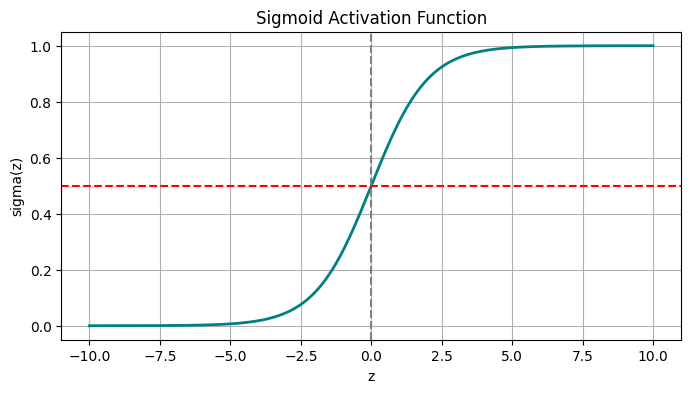

In [2]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z_values = np.linspace(-10, 10, 200)
sigmoid_values = sigmoid(z_values)
plt.figure(figsize=(8, 4))
plt.plot(z_values, sigmoid_values, color="teal", linewidth=2)
plt.axhline(0.5, color="red", linestyle="--")
plt.axvline(0, color="gray", linestyle="--")
plt.xlabel("z")
plt.ylabel("sigma(z)")
plt.title("Sigmoid Activation Function")
plt.grid(True)
plt.show()


## Load Dataset


In [3]:
data = load_breast_cancer()
X = data.data
y = data.target


## Preprocessing


In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


## Model Training


In [5]:
model = LogisticRegression(random_state=42)
model.fit(X_train, y_train)


## Prediction


In [6]:
probabilities = model.predict_proba(X_test)
y_pred = model.predict(X_test)
print("Predicted Probabilities (first 5 samples):")
print(probabilities[:5])
print("\nPredicted Classes (first 5 samples):")
print(y_pred[:5])


Predicted Probabilities (first 5 samples):
[[9.99999941e-01 5.88824186e-08]
 [1.13351672e-05 9.99988665e-01]
 [9.93589175e-01 6.41082462e-03]
 [4.66491463e-01 5.33508537e-01]
 [9.99999999e-01 6.52500097e-10]]

Predicted Classes (first 5 samples):
[0 1 0 1 0]


## Evaluation


In [7]:
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred, target_names=data.target_names)
print(f"Accuracy: {accuracy:.4f}\n")
print("Confusion Matrix:")
print(conf_matrix)
print("\nClassification Report:")
print(report)


Accuracy: 0.9825

Confusion Matrix:
[[41  1]
 [ 1 71]]

Classification Report:
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



## Visualization


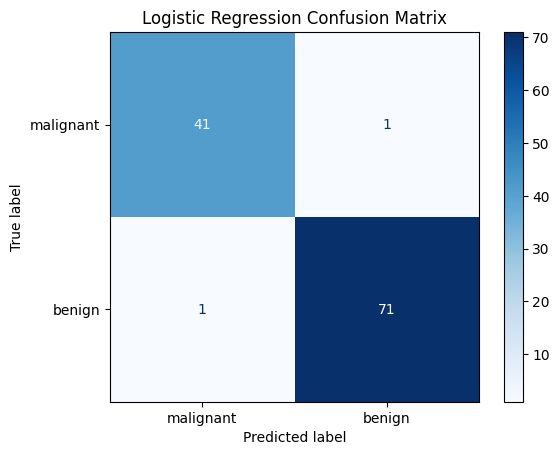

In [8]:
display = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=data.target_names)
display.plot(cmap="Blues")
plt.title("Logistic Regression Confusion Matrix")
plt.show()
